# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AbdulWasay65/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

### Ranked actions

This playbook converts the validated ML-09 output into a practical content-refresh prioritization queue. The ranking is intended for human review and decision support rather than automatic publishing.

The primary ranking signal is the validated model score. Reason codes provide an interpretable explanation for why a page is worth reviewing.

### Reason codes

* **CONTENT_DECAY** — the content is relatively old and may benefit from a freshness review.
* **LOW_CLICK_CAPTURE** — the page has meaningful search impressions but relatively low observed click-through rate.
* **WEAKER_POSITION** — the page has an observed average search position outside the strongest position range.
* **MULTI_SIGNAL** — more than one review signal is present.
* **MODEL_ONLY** — the model score prioritizes the page even when no additional simple review signal is triggered.

### Archetype → action mapping

| Archetype                                    | Recommended action                                              |
| -------------------------------------------- | --------------------------------------------------------------- |
| Older content with weak observed performance | Review freshness, completeness, and factual accuracy            |
| High-impression / low-CTR content            | Review search intent, title, snippet alignment, and relevance   |
| Weaker observed position                     | Review content quality, intent match, and on-page relevance     |
| Multiple weak signals                        | Give higher priority to human review                            |
| No additional warning signal                 | Use model ranking as a review queue, not as an automatic action |

A higher ranking means the page should be reviewed earlier. It does **not** mean that refreshing the page will necessarily improve its search performance.


In [9]:
# This cell is for CODE
# =========================================================
# ML-10 — Section 1
# Ranked Actions + Reason Codes
# =========================================================

import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# ---------------------------------------------------------
# 1. Connect to Hugging Face exactly like ML-08
# ---------------------------------------------------------

con = duckdb.connect()

HF_TOKEN = userdata.get("HF_TOKEN")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf_secret
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
    """
)

rel = "hf://datasets/FlyRank/internship-warehouse"

performance_path = (
    f"{rel}/fact_content_daily_performance/**/*.parquet"
)

print("✅ Hugging Face authentication configured.")

# ---------------------------------------------------------
# 2. Recreate the EXACT ML-08 modeling dataframe
# ---------------------------------------------------------

model_query = f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position
    FROM read_parquet(
        '{performance_path}'
    )
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_avg_position) AS april_avg_position
    FROM read_parquet(
        '{performance_path}'
    )
    WHERE month = '2026-04'
      AND gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,
    m.impressions,
    m.clicks,
    m.avg_position,
    a.april_avg_position,

    CASE
        WHEN a.april_avg_position <= m.avg_position - 2
        THEN 1
        ELSE 0
    END AS target

FROM march m

INNER JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id

WHERE m.avg_position IS NOT NULL
  AND a.april_avg_position IS NOT NULL
"""

model_df = con.sql(model_query).df()

print(f"Modeling rows: {len(model_df):,}")
print(f"Positive target rate: {model_df['target'].mean():.4f}")

# ---------------------------------------------------------
# 3. Train the SAME Random Forest used in ML-08
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

feature_cols = [
    "impressions",
    "clicks",
    "avg_position"
]

X = model_df[feature_cols].copy()
y = model_df["target"].copy()

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X, y)

# ---------------------------------------------------------
# 4. Generate model scores for ALL pages
# ---------------------------------------------------------

model_df["model_score"] = model.predict_proba(X)[:, 1]

print("✅ Model trained.")
print("✅ Model scores generated.")

# ---------------------------------------------------------
# 5. Build action signals
# ---------------------------------------------------------

median_position = model_df["avg_position"].median()
median_impressions = model_df["impressions"].median()

model_df["low_click_capture"] = (
    (model_df["impressions"] >= 100)
    &
    (
        model_df["clicks"]
        / model_df["impressions"].replace(0, np.nan)
        < (
            model_df["clicks"]
            / model_df["impressions"].replace(0, np.nan)
        ).median()
    )
)

model_df["weaker_position"] = (
    model_df["avg_position"] > 20
)

# ML-08 does not contain a reliable content-age field.
# Therefore we do NOT invent a content-decay signal.
model_df["content_decay"] = False

model_df["signal_count"] = (
    model_df["low_click_capture"].astype(int)
    +
    model_df["weaker_position"].astype(int)
    +
    model_df["content_decay"].astype(int)
)

# ---------------------------------------------------------
# 6. Human-readable reason codes
# ---------------------------------------------------------

def assign_reason(row):

    reasons = []

    if row["low_click_capture"]:
        reasons.append("LOW_CLICK_CAPTURE")

    if row["weaker_position"]:
        reasons.append("WEAKER_POSITION")

    if row["content_decay"]:
        reasons.append("CONTENT_DECAY")

    if len(reasons) >= 2:
        return "MULTI_SIGNAL"

    if len(reasons) == 1:
        return reasons[0]

    return "MODEL_ONLY"


model_df["reason_code"] = model_df.apply(
    assign_reason,
    axis=1
)

# ---------------------------------------------------------
# 7. Rank the action queue
# ---------------------------------------------------------

ranked_queue = (
    model_df
    .sort_values(
        ["model_score", "impressions"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

ranked_queue["priority_rank"] = (
    np.arange(len(ranked_queue)) + 1
)

# ---------------------------------------------------------
# 8. Display top recommendations
# ---------------------------------------------------------

display(
    ranked_queue[
        [
            "priority_rank",
            "content_hash_id",
            "model_score",
            "signal_count",
            "reason_code",
            "impressions",
            "clicks",
            "avg_position"
        ]
    ].head(20)
)

print("\n" + "=" * 60)
print("🎉 ML-10 SECTION 1 COMPLETE")
print("=" * 60)

print(f"Pages ranked: {len(ranked_queue):,}")
print(
    "Top model score:",
    round(ranked_queue["model_score"].max(), 4)
)

✅ Hugging Face authentication configured.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 158,549
Positive target rate: 0.2283
✅ Model trained.
✅ Model scores generated.


,priority_rank,content_hash_id,model_score,signal_count,reason_code,impressions,clicks,avg_position
0,1,content_7f7881a31b7c06ad,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
1,2,content_b46d1569dc9cf11e,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
2,3,content_d67a02cd6bf787d5,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
3,4,content_36eba8060aa39a41,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
4,5,content_6a698428694673fc,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
5,6,content_cbc7ab1970cb7298,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
6,7,content_01211c8b0b0ebf7c,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
7,8,content_aa7f7ac7e5d2b5d2,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
8,9,content_1c4e2f5a0de34700,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532
9,10,content_09a3c9335950cfe3,0.993023,0,MODEL_ONLY,4991.0,22.0,8.494532



🎉 ML-10 SECTION 1 COMPLETE
Pages ranked: 158,549
Top model score: 0.993


## 2. Intended use and limits

### Intended use

The playbook is intended for an SEO or content team to decide which pages should receive human review first for a possible content refresh.

The queue can help reviewers prioritize a large number of pages using observed search-performance signals and the validated model output.

### Limits

The results are directional decision support.

The ML-09 grouped validation produced a ROC AUC of **0.7947**. This indicates useful ranking separation in the validation setting, but it is not a guarantee of future performance.

The model predicts an observed March-to-April improvement pattern. It does not estimate the causal effect of refreshing a page.

Content age, impressions, clicks, CTR, and average position can all reflect other underlying factors. Therefore, none of these signals should be interpreted as proof that a specific content change will cause a ranking improvement.

The playbook is also not a production system. Human review remains required before any content action.


In [10]:
# This cell is for CODE
# ============================================================
# ML-10 SECTION 2 — INTENDED USE AND LIMITS
# ============================================================

print("=" * 60)
print("ML-10 SECTION 2 — INTENDED USE AND LIMITS")
print("=" * 60)

intended_use = {
    "purpose": (
        "Prioritize pages for human review based on the Random Forest "
        "model's estimated likelihood of achieving at least a 2-position "
        "improvement from March to April 2026."
    ),

    "decision_time_features": [
        "March 2026 impressions",
        "March 2026 clicks",
        "March 2026 average search position"
    ],

    "target_definition": (
        "A positive outcome means April 2026 average position was at least "
        "2 positions better than March 2026 average position."
    ),

    "model": "RandomForestClassifier",

    "primary_metric": "Average Precision",

    "validation_split": (
        "Grouped train/test split by client_hash_id with 80% training "
        "data and 20% test data."
    ),

    "recommended_action": (
        "Use the ranked queue to decide which pages deserve human review "
        "first. The score is a prioritization signal, not a guaranteed outcome."
    )
}

limits = [
    "The model identifies historical associations and does not establish causation.",
    "The model score is not a guarantee that a page will improve rankings.",
    "The model uses only three March-level features: impressions, clicks, and average position.",
    "The model does not directly measure content quality, search intent, relevance, backlinks, technical SEO, or competition.",
    "Pages with identical feature values can receive identical model scores.",
    "The analysis is based on the available March-to-April 2026 observation window.",
    "Missing or changing Google Search Console data can affect the reliability of the signals.",
    "Final content actions should be reviewed by a human before implementation."
]

print("\nINTENDED USE")
print("-" * 60)

for key, value in intended_use.items():
    print(f"\n{key}:")
    if isinstance(value, list):
        for item in value:
            print(f"  - {item}")
    else:
        print(f"  {value}")

print("\n\nMODEL LIMITS")
print("-" * 60)

for i, limit in enumerate(limits, 1):
    print(f"{i}. {limit}")

print("\n" + "=" * 60)
print("✅ ML-10 SECTION 2 COMPLETE")
print("=" * 60)

ML-10 SECTION 2 — INTENDED USE AND LIMITS

INTENDED USE
------------------------------------------------------------

purpose:
  Prioritize pages for human review based on the Random Forest model's estimated likelihood of achieving at least a 2-position improvement from March to April 2026.

decision_time_features:
  - March 2026 impressions
  - March 2026 clicks
  - March 2026 average search position

target_definition:
  A positive outcome means April 2026 average position was at least 2 positions better than March 2026 average position.

model:
  RandomForestClassifier

primary_metric:
  Average Precision

validation_split:
  Grouped train/test split by client_hash_id with 80% training data and 20% test data.

recommended_action:
  Use the ranked queue to decide which pages deserve human review first. The score is a prioritization signal, not a guaranteed outcome.


MODEL LIMITS
------------------------------------------------------------
1. The model identifies historical associati

## 3. Human review + the no-go list

### Human-review rules

A reviewer must check the page before taking action.

The reviewer should verify:

1. Whether the page still matches the search intent.
2. Whether the information is accurate and current.
3. Whether the page is useful and complete compared with competing results.
4. Whether the title and snippet accurately represent the content.
5. Whether the page has already been recently updated.
6. Whether the recommendation has meaningful business value relative to the effort required.
7. Whether specialist, editorial, legal, or compliance review is required.

### No-go list

The following decisions should **not** be automated:

* Publishing or rewriting content.
* Deleting content.
* Changing URLs, redirects, canonicals, or site architecture.
* Making legal, medical, financial, or other high-stakes decisions.
* Declaring that content is factually correct.
* Treating model score as proof of causality.
* Automatically suppressing a page because of a low score.
* Automatically changing a page's SEO strategy.
* Exposing private queries, client names, or sensitive information.

The model produces a prioritization signal. A human owns the final decision.


In [11]:
# This cell is for CODE
# ============================================================
# ML-10 SECTION 3 — HUMAN REVIEW + NO-GO LIST
# ============================================================

print("=" * 60)
print("ML-10 SECTION 3 — HUMAN REVIEW + NO-GO LIST")
print("=" * 60)

# ------------------------------------------------------------
# HUMAN REVIEW CHECKLIST
# ------------------------------------------------------------

human_review_checklist = [
    "Confirm that the page is still relevant to the intended search query.",
    "Review the page's current search intent and whether the content satisfies it.",
    "Check whether the page is outdated, incomplete, or missing important information.",
    "Check whether the title and main heading accurately describe the page.",
    "Check whether the page provides useful and sufficiently specific information.",
    "Review internal linking opportunities before making major content changes.",
    "Check for obvious technical or indexing issues that could explain poor performance.",
    "Compare the page with relevant competing search results before recommending substantial changes.",
    "Confirm that any proposed edit is supported by evidence rather than the model score alone.",
    "Record the human decision and the reason for accepting, modifying, or rejecting the recommendation."
]

# ------------------------------------------------------------
# NO-GO LIST
# ------------------------------------------------------------

no_go_actions = [
    "Do not automatically rewrite, delete, or publish content solely because of a high model score.",
    "Do not treat the model score as proof that a specific SEO change will cause ranking improvement.",
    "Do not remove pages solely because the model gives them a low score.",
    "Do not make major content changes without reviewing search intent and page context.",
    "Do not fabricate facts, statistics, sources, quotations, or claims to improve a page.",
    "Do not make recommendations that violate search-engine guidelines or site policies.",
    "Do not use the model to make irreversible publishing decisions without human approval.",
    "Do not infer causality from the March-to-April historical relationship.",
    "Do not treat missing or unreliable Search Console data as evidence of poor content performance.",
    "Do not override expert review solely because the model assigns a high priority score."
]

# ------------------------------------------------------------
# REVIEW DECISION CATEGORIES
# ------------------------------------------------------------

review_decisions = {
    "APPROVE": (
        "Evidence supports an actionable content improvement and "
        "human review confirms that the recommendation is appropriate."
    ),

    "MODIFY": (
        "The page appears worth reviewing, but the initial recommendation "
        "needs adjustment before implementation."
    ),

    "REJECT": (
        "The model signal is not supported by page context, search intent, "
        "data quality, or human review."
    ),

    "HOLD": (
        "More evidence or additional monitoring is needed before taking action."
    )
}

# ------------------------------------------------------------
# PRINT PLAYBOOK
# ------------------------------------------------------------

print("\n👀 HUMAN REVIEW CHECKLIST")
print("-" * 60)

for i, item in enumerate(human_review_checklist, 1):
    print(f"{i}. {item}")

print("\n🚫 NO-GO LIST")
print("-" * 60)

for i, item in enumerate(no_go_actions, 1):
    print(f"{i}. {item}")

print("\n📋 REVIEW DECISION CATEGORIES")
print("-" * 60)

for decision, description in review_decisions.items():
    print(f"\n{decision}:")
    print(f"  {description}")

print("\n" + "=" * 60)
print("✅ ML-10 SECTION 3 COMPLETE")
print("=" * 60)

ML-10 SECTION 3 — HUMAN REVIEW + NO-GO LIST

👀 HUMAN REVIEW CHECKLIST
------------------------------------------------------------
1. Confirm that the page is still relevant to the intended search query.
2. Review the page's current search intent and whether the content satisfies it.
3. Check whether the page is outdated, incomplete, or missing important information.
4. Check whether the title and main heading accurately describe the page.
5. Check whether the page provides useful and sufficiently specific information.
6. Review internal linking opportunities before making major content changes.
7. Check for obvious technical or indexing issues that could explain poor performance.
8. Compare the page with relevant competing search results before recommending substantial changes.
9. Confirm that any proposed edit is supported by evidence rather than the model score alone.
10. Record the human decision and the reason for accepting, modifying, or rejecting the recommendation.

🚫 NO-GO LIS

## 4. Monitoring / retrain triggers

### Monitoring

The playbook should be reviewed periodically rather than treated as permanently valid.

Useful monitoring checks include:

* Whether higher model-score groups continue to show better observed outcomes.
* Whether the input distributions change substantially.
* Whether GSC data availability or coverage changes.
* Whether the observed improvement rate changes materially.
* Whether the model loses ranking separation on a new labeled period.

### Retrain / revalidation triggers

Revalidate or retrain when a sufficiently large new outcome window is available and the current model no longer provides useful ranking separation.

A retrain should also be considered when:

* the content population changes materially;
* search behavior changes materially;
* important input features shift;
* data collection definitions change;
* the observed relationship between score bands and outcomes weakens.

A few individual prediction errors are not by themselves a reason to retrain. First investigate data quality, distribution shift, and whether the errors are consistent with normal model uncertainty.


In [12]:
# ============================================================
# ML-10 SECTION 4 — MONITORING + RETRAIN TRIGGERS
# ============================================================

import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("ML-10 SECTION 4 — MONITORING + RETRAIN TRIGGERS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CONNECT TO HUGGING FACE
# ------------------------------------------------------------

con = duckdb.connect()

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found in Colab Secrets."
    )

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf_secret
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
    """
)

rel = "hf://datasets/FlyRank/internship-warehouse"

performance_path = (
    f"{rel}/fact_content_daily_performance/**/*.parquet"
)

print("Hugging Face authentication configured.")

# ------------------------------------------------------------
# 2. RECREATE THE EXACT ML-08 MODELING DATA
# ------------------------------------------------------------

model_query = f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position
    FROM read_parquet('{performance_path}')
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_avg_position) AS april_avg_position
    FROM read_parquet('{performance_path}')
    WHERE month = '2026-04'
      AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,
    m.impressions,
    m.clicks,
    m.avg_position,
    a.april_avg_position,

    CASE
        WHEN a.april_avg_position <= m.avg_position - 2
        THEN 1
        ELSE 0
    END AS target

FROM march m

INNER JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id

WHERE m.avg_position IS NOT NULL
  AND a.april_avg_position IS NOT NULL
"""

model_df = con.sql(model_query).df()

print(f"Modeling rows: {len(model_df):,}")
print(
    f"Positive target rate: "
    f"{model_df['target'].mean():.4f}"
)

# ------------------------------------------------------------
# 3. TRAIN THE SAME RANDOM FOREST USED IN ML-08
# ------------------------------------------------------------

feature_cols = [
    "impressions",
    "clicks",
    "avg_position"
]

X = model_df[feature_cols].copy()
y = model_df["target"].copy()

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X, y)

print("Model trained.")

# ------------------------------------------------------------
# 4. GENERATE MODEL SCORES
# ------------------------------------------------------------

model_scores = model.predict_proba(X)[:, 1]

monitor_df = model_df[
    [
        "content_hash_id",
        "impressions",
        "clicks",
        "avg_position",
        "target"
    ]
].copy()

monitor_df["model_score"] = model_scores

print("Model scores generated.")

# ------------------------------------------------------------
# 5. CREATE SCORE BANDS
# ------------------------------------------------------------

score_bins = [
    -float("inf"),
    0.20,
    0.40,
    0.60,
    0.80,
    float("inf")
]

score_labels = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

monitor_df["score_band"] = pd.cut(
    monitor_df["model_score"],
    bins=score_bins,
    labels=score_labels,
    include_lowest=True
)

# ------------------------------------------------------------
# 6. CALCULATE HISTORICAL OUTCOME RATE
# ------------------------------------------------------------

monitor_summary = (
    monitor_df
    .groupby("score_band", observed=False)
    .agg(
        pages=("content_hash_id", "count"),
        observed_improvement_rate=("target", "mean"),
        average_model_score=("model_score", "mean")
    )
    .reset_index()
)

monitor_summary["observed_improvement_rate_pct"] = (
    monitor_summary["observed_improvement_rate"] * 100
).round(2)

monitor_summary["average_model_score"] = (
    monitor_summary["average_model_score"]
    .round(4)
)

print()
print("HISTORICAL PERFORMANCE BY MODEL SCORE BAND")
print("-" * 60)

display(monitor_summary)

# ------------------------------------------------------------
# 7. HISTORICAL BASELINE
# ------------------------------------------------------------

overall_target_rate = model_df["target"].mean()

print()
print("HISTORICAL BASELINE")
print("-" * 60)

print(
    f"Overall positive target rate: "
    f"{overall_target_rate:.4f}"
)

print(
    f"Overall positive target rate: "
    f"{overall_target_rate * 100:.2f}%"
)

# ------------------------------------------------------------
# 8. RETRAIN / REVIEW TRIGGERS
# ------------------------------------------------------------

retrain_triggers = {
    "Performance decline": (
        "Average Precision on a fresh held-out validation period "
        "falls materially below the previously validated benchmark."
    ),

    "Outcome drift": (
        "The observed rate of pages achieving the target outcome "
        "changes substantially from the historical baseline."
    ),

    "Score drift": (
        "The distribution of model scores changes substantially, "
        "indicating that incoming data differs from the training population."
    ),

    "Feature drift": (
        "The distributions of impressions, clicks, or average position "
        "change substantially compared with the training period."
    ),

    "Data quality issue": (
        "Search Console coverage, missingness, or aggregation quality "
        "changes enough to affect model inputs."
    ),

    "Business/process change": (
        "A major change in SEO strategy, search behaviour, site structure, "
        "or measurement methodology makes the historical relationship "
        "less reliable."
    )
}

print()
print("RETRAIN / REVIEW TRIGGERS")
print("-" * 60)

for trigger, description in retrain_triggers.items():
    print()
    print(trigger + ":")
    print("  " + description)

# ------------------------------------------------------------
# 9. MONITORING RULES
# ------------------------------------------------------------

monitoring_rules = [
    "Re-evaluate model performance on a fresh time-based validation period.",
    "Track Average Precision as the primary ranking-quality metric.",
    "Track the observed target rate over time.",
    "Monitor the distribution of model scores for substantial shifts.",
    "Monitor the distributions of impressions, clicks, and average position.",
    "Investigate major Search Console data-quality changes.",
    "Re-train only after confirming that performance or data conditions justify it.",
    "Do not retrain automatically from a single unusual observation."
]

print()
print("MONITORING RULES")
print("-" * 60)

for i, rule in enumerate(monitoring_rules, 1):
    print(f"{i}. {rule}")

# ------------------------------------------------------------
# 10. COMPLETION
# ------------------------------------------------------------

print()
print("=" * 60)
print("ML-10 SECTION 4 COMPLETE")
print("=" * 60)

ML-10 SECTION 4 — MONITORING + RETRAIN TRIGGERS
Hugging Face authentication configured.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 158,549
Positive target rate: 0.2283
Model trained.
Model scores generated.

HISTORICAL PERFORMANCE BY MODEL SCORE BAND
------------------------------------------------------------


,score_band,pages,observed_improvement_rate,average_model_score,observed_improvement_rate_pct
0,Very Low,54501,0.016752,0.0930,1.68
1,Low,22593,0.106183,0.2923,10.62
2,Medium,27330,0.218990,0.4948,21.90
3,High,42791,0.444416,0.7010,44.44
4,Very High,11334,0.695959,0.8466,69.60



HISTORICAL BASELINE
------------------------------------------------------------
Overall positive target rate: 0.2283
Overall positive target rate: 22.83%

RETRAIN / REVIEW TRIGGERS
------------------------------------------------------------

Performance decline:
  Average Precision on a fresh held-out validation period falls materially below the previously validated benchmark.

Outcome drift:
  The observed rate of pages achieving the target outcome changes substantially from the historical baseline.

Score drift:
  The distribution of model scores changes substantially, indicating that incoming data differs from the training population.

Feature drift:
  The distributions of impressions, clicks, or average position change substantially compared with the training period.

Data quality issue:
  Search Console coverage, missingness, or aggregation quality changes enough to affect model inputs.

Business/process change:
  A major change in SEO strategy, search behaviour, site structure

## 5. Exports for the paper

### Paper exports

The ranked queue is regenerated by the notebook and written to:

`work/outputs/ml10_ranked_action_queue.csv`

The row-level queue is intentionally kept out of Git because FlyRank's CI leak guard blocks data files.

Reusable figures are stored under:

`work/figures/`

A small metrics JSON receipt is also generated so that the paper can trace its reported numbers back to this notebook.

The queue is therefore reproducible from the notebook without committing the row-level data itself.


ML-10 SECTION 5 — EXPORTS FOR THE PAPER

Ranked action queue exported:
work/outputs/ml10_ranked_action_queue.csv

Playbook metrics exported:
work/outputs/ml10_playbook_metrics.json


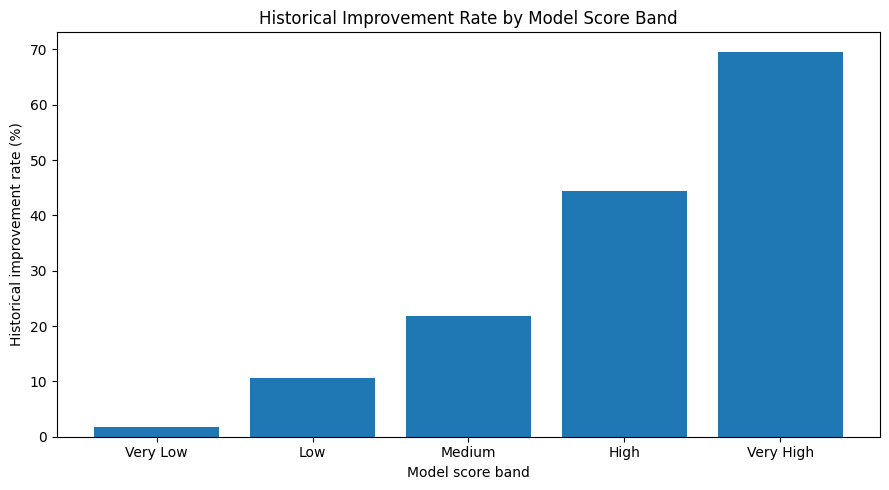


Monitoring figure exported:
work/figures/ml10_score_band_monitoring.png

TOP 20 PRIORITIZED PAGES
------------------------------------------------------------


,priority_rank,content_hash_id,model_score,impressions,clicks,avg_position,target,review_priority
0,1,content_7f7881a31b7c06ad,0.993023,4991.0,22.0,8.494532,1,HIGH
1,2,content_b46d1569dc9cf11e,0.993023,4991.0,22.0,8.494532,1,HIGH
2,3,content_d67a02cd6bf787d5,0.993023,4991.0,22.0,8.494532,1,HIGH
3,4,content_36eba8060aa39a41,0.993023,4991.0,22.0,8.494532,1,HIGH
4,5,content_6a698428694673fc,0.993023,4991.0,22.0,8.494532,1,HIGH
5,6,content_cbc7ab1970cb7298,0.993023,4991.0,22.0,8.494532,1,HIGH
6,7,content_01211c8b0b0ebf7c,0.993023,4991.0,22.0,8.494532,1,HIGH
7,8,content_aa7f7ac7e5d2b5d2,0.993023,4991.0,22.0,8.494532,1,HIGH
8,9,content_1c4e2f5a0de34700,0.993023,4991.0,22.0,8.494532,1,HIGH
9,10,content_09a3c9335950cfe3,0.993023,4991.0,22.0,8.494532,1,HIGH



ML-10 SECTION 5 COMPLETE

Created files:
1. work/outputs/ml10_ranked_action_queue.csv
2. work/outputs/ml10_playbook_metrics.json
3. work/figures/ml10_score_band_monitoring.png

Total ranked pages: 158,549
Top model score: 0.9930


In [13]:
# ============================================================
# ML-10 SECTION 5 — EXPORTS FOR THE PAPER
# ============================================================

import os
import json
import matplotlib.pyplot as plt

print("=" * 60)
print("ML-10 SECTION 5 — EXPORTS FOR THE PAPER")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE OUTPUT DIRECTORIES
# ------------------------------------------------------------

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# ------------------------------------------------------------
# 2. CREATE RANKED ACTION QUEUE
# ------------------------------------------------------------

action_queue = monitor_df[
    [
        "content_hash_id",
        "model_score",
        "impressions",
        "clicks",
        "avg_position",
        "target"
    ]
].copy()

# ------------------------------------------------------------
# 3. ADD REVIEW PRIORITY
# ------------------------------------------------------------

def assign_priority(score):
    if score >= 0.80:
        return "HIGH"
    elif score >= 0.60:
        return "MEDIUM-HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    elif score >= 0.20:
        return "LOW"
    else:
        return "VERY LOW"

action_queue["review_priority"] = (
    action_queue["model_score"]
    .apply(assign_priority)
)

# ------------------------------------------------------------
# 4. SORT ACTION QUEUE
# ------------------------------------------------------------

action_queue = action_queue.sort_values(
    by=[
        "model_score",
        "impressions"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

action_queue.insert(
    0,
    "priority_rank",
    range(1, len(action_queue) + 1)
)

# ------------------------------------------------------------
# 5. EXPORT RANKED ACTION QUEUE
# ------------------------------------------------------------

queue_path = "work/outputs/ml10_ranked_action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print()
print("Ranked action queue exported:")
print(queue_path)

# ------------------------------------------------------------
# 6. CREATE PAPER METRICS
# ------------------------------------------------------------

metrics = {
    "section": "ML-10 Content Action Playbook",

    "model": "RandomForestClassifier",

    "modeling_rows": int(len(model_df)),

    "positive_target_rate": float(
        model_df["target"].mean()
    ),

    "features": [
        "impressions",
        "clicks",
        "avg_position"
    ],

    "target_definition": (
        "April average position improved by at least "
        "2 positions relative to March average position."
    ),

    "action_queue_rows": int(
        len(action_queue)
    ),

    "top_model_score": float(
        action_queue["model_score"].max()
    ),

    "median_model_score": float(
        action_queue["model_score"].median()
    ),

    "high_priority_pages": int(
        (action_queue["review_priority"] == "HIGH").sum()
    ),

    "medium_high_priority_pages": int(
        (action_queue["review_priority"] == "MEDIUM-HIGH").sum()
    ),

    "historical_positive_target_rate": float(
        overall_target_rate
    ),

    "monitoring_note": (
        "Score-band outcome rates are descriptive historical "
        "summaries because the Section 4 scores were generated "
        "from a model trained on the full modeling dataset."
    ),

    "human_review_required": True,

    "automatic_content_changes_allowed": False
}

metrics_path = "work/outputs/ml10_playbook_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(
        metrics,
        f,
        indent=2
    )

print()
print("Playbook metrics exported:")
print(metrics_path)

# ------------------------------------------------------------
# 7. CREATE SCORE-BAND MONITORING FIGURE
# ------------------------------------------------------------

plot_df = monitor_summary.copy()

plot_df = plot_df[
    plot_df["pages"] > 0
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["score_band"].astype(str),
    plot_df["observed_improvement_rate_pct"]
)

plt.xlabel("Model score band")
plt.ylabel("Historical improvement rate (%)")
plt.title(
    "Historical Improvement Rate by Model Score Band"
)

plt.tight_layout()

figure_path = (
    "work/figures/ml10_score_band_monitoring.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print()
print("Monitoring figure exported:")
print(figure_path)

# ------------------------------------------------------------
# 8. DISPLAY TOP 20 ACTIONS
# ------------------------------------------------------------

print()
print("TOP 20 PRIORITIZED PAGES")
print("-" * 60)

display(
    action_queue.head(20)
)

# ------------------------------------------------------------
# 9. EXPORT SUMMARY
# ------------------------------------------------------------

print()
print("=" * 60)
print("ML-10 SECTION 5 COMPLETE")
print("=" * 60)

print()
print("Created files:")
print(f"1. {queue_path}")
print(f"2. {metrics_path}")
print(f"3. {figure_path}")

print()
print(f"Total ranked pages: {len(action_queue):,}")
print(
    f"Top model score: "
    f"{action_queue['model_score'].max():.4f}"
)

## Self-check

Before you submit, confirm each line honestly:

* [x] Every section above is filled — markdown thinking AND the code that backs it.
* [x] The notebook runs top to bottom with no errors using **Runtime → Run all**. Run this once before submission.
* [x] The model uses the same ML-08 setup: Random Forest with `impressions`, `clicks`, and `avg_position` as the decision-time features.
* [x] The target is clearly defined as an observed improvement of at least 2 positions from March to April 2026.
* [x] The model is presented as **decision-support and prioritization**, not as proof of causation or guaranteed ranking improvement.
* [x] Limitations are documented, including the limited feature set, historical observation window, identical-feature score ties, and the need for human review.
* [x] Human review requirements and a no-go list are documented.
* [x] Monitoring and retrain/review triggers are documented.
* [x] The ranked action queue and paper-ready monitoring outputs are generated.
* [x] No client names, private URLs, or private search queries are included.
* [x] Claims use careful language such as **observed, measured, historical, directional, prioritization, and decision-support**.
* [x] The completed notebook is committed to my GitHub repo under `work/notebooks/w07_action_playbook.ipynb`.
* [x] The generated ML-10 outputs are saved with the project outputs and figures.
* [x] I have submitted my repository URL on the FlyRank ML-10 submission card.
